<h1 style="color: red;"><b><i> Student Admission Analysis </i></b></h1>

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px


In [2]:
df=pd.read_csv("student.csv")
print(df)



    StudentID  ApplicationNo     StudentName       FatherName Category  \
0        S101          58432      Aman Singh    Sukhdev Singh  General   
1        S102          91204  Ananya Majokha   Ramesh Majokha      OBC   
2        S103          40219     Rohit Gupta     Satish Gupta      EWS   
3        S104          83105   Ishita Bansal    Sanjay Bansal  General   
4        S105          12984    Kabir Sharma     Vijay Sharma  General   
..        ...            ...             ...              ...      ...   
195      S296          23965    Kunal Singla  Joginder Singla  General   
196      S297          89921    Rishi Kansal      Anil Kansal       ST   
197      S298          45987   Shashank Garg      Sanjay Garg      EWS   
198      S299          90933  Yashika Jindal    Satbir Jindal  General   
199      S300          56998   Kavita Mittal    Rajesh Mittal      OBC   

        City  Class12_Percentage  CS_Marks Stream_Preference  
0    Kaithal                88.5      92.0      

In [3]:
print(df.isnull().sum())

StudentID             0
ApplicationNo         0
StudentName           0
FatherName            0
Category              0
City                  0
Class12_Percentage    5
CS_Marks              4
Stream_Preference     0
dtype: int64


In [4]:
print("Duplicate rows count:", df.duplicated(subset=['StudentID']).sum())

Duplicate rows count: 0


In [8]:
df['Class12_Percentage'] = df['Class12_Percentage'].fillna(0)
print(df)

    StudentID  ApplicationNo     StudentName       FatherName Category  \
0        S101          58432      Aman Singh    Sukhdev Singh  General   
1        S102          91204  Ananya Majokha   Ramesh Majokha      OBC   
2        S103          40219     Rohit Gupta     Satish Gupta      EWS   
3        S104          83105   Ishita Bansal    Sanjay Bansal  General   
4        S105          12984    Kabir Sharma     Vijay Sharma  General   
..        ...            ...             ...              ...      ...   
195      S296          23965    Kunal Singla  Joginder Singla  General   
196      S297          89921    Rishi Kansal      Anil Kansal       ST   
197      S298          45987   Shashank Garg      Sanjay Garg      EWS   
198      S299          90933  Yashika Jindal    Satbir Jindal  General   
199      S300          56998   Kavita Mittal    Rajesh Mittal      OBC   

        City  Class12_Percentage  CS_Marks Stream_Preference  
0    Kaithal                88.5      92.0      

In [14]:

pd.set_option('display.max_columns', 50)


pd.set_option('display.expand_frame_repr', False)
print(df)

    StudentID  ApplicationNo     StudentName       FatherName Category     City  Class12_Percentage  CS_Marks Stream_Preference
0        S101          58432      Aman Singh    Sukhdev Singh  General  Kaithal                88.5      92.0             BTech
1        S102          91204  Ananya Majokha   Ramesh Majokha      OBC    Siwan                76.2      85.0               BCA
2        S103          40219     Rohit Gupta     Satish Gupta      EWS   Cheeka                 0.0      78.0               BSc
3        S104          83105   Ishita Bansal    Sanjay Bansal  General   Tohana                94.0      98.0             BTech
4        S105          12984    Kabir Sharma     Vijay Sharma  General    Silsa                65.8      70.0               BCA
..        ...            ...             ...              ...      ...      ...                 ...       ...               ...
195      S296          23965    Kunal Singla  Joginder Singla  General    Silsa                81.1     

In [13]:

median_val = df['Class12_Percentage'].median()
df['Class12_Percentage'] = df['Class12_Percentage'].fillna(median_val)


df['CS_Marks'] = df['CS_Marks'].fillna(0)
print(median_val)

78.9


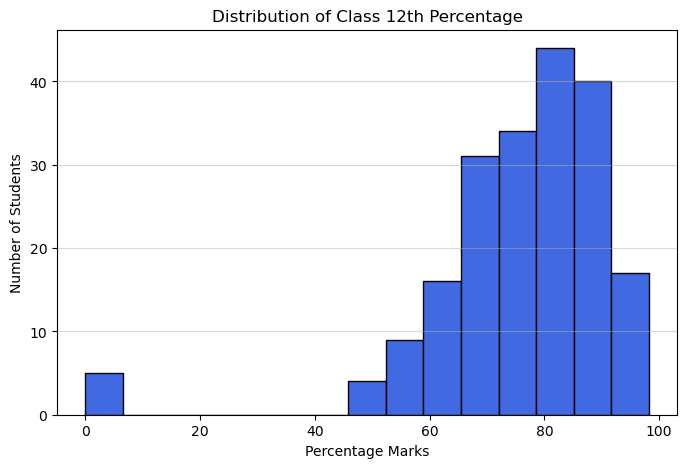

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['Class12_Percentage'].dropna(), bins=15, color='royalblue', edgecolor='black')
plt.title('Distribution of Class 12th Percentage')
plt.xlabel('Percentage Marks')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.5)
plt.show()

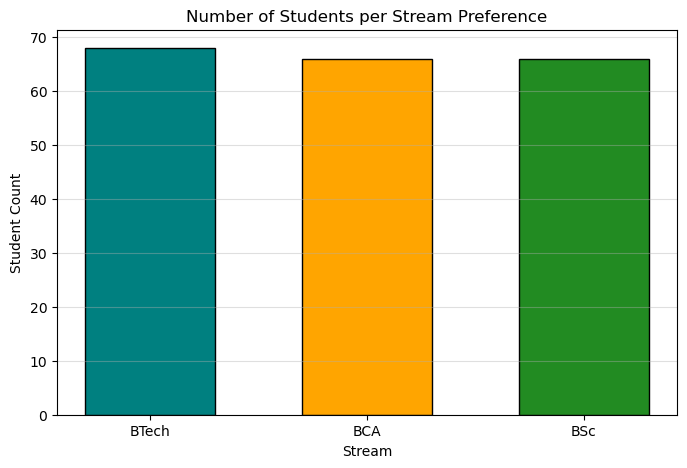

In [19]:
stream_counts = df['Stream_Preference'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(stream_counts.index, stream_counts.values, color=['teal', 'orange', 'forestgreen'], edgecolor='black', width=0.6)
plt.title('Number of Students per Stream Preference')
plt.xlabel('Stream')
plt.ylabel('Student Count')
plt.grid(axis='y', alpha=0.4)
plt.show()

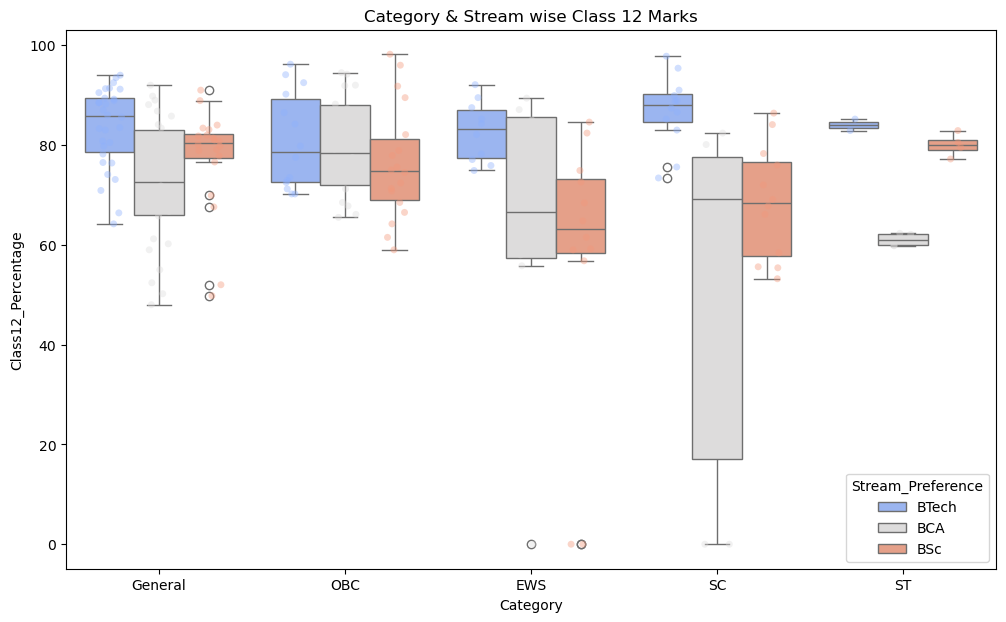

In [20]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Category', y='Class12_Percentage', data=df, hue='Stream_Preference', palette='coolwarm')
sns.stripplot(x='Category', y='Class12_Percentage', data=df, hue='Stream_Preference', dodge=True, alpha=0.4, jitter=0.2, palette='coolwarm', legend=False)
plt.title('Category & Stream wise Class 12 Marks')
plt.show()

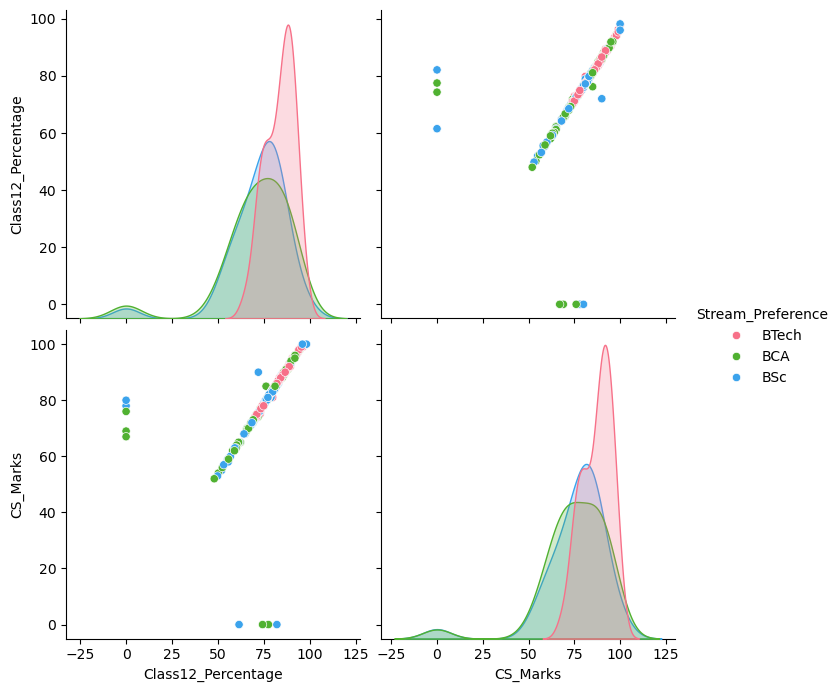

In [22]:
sns.pairplot(df[['Class12_Percentage', 'CS_Marks', 'Stream_Preference']], hue='Stream_Preference', palette='husl', height=3.5)
plt.show()

In [32]:
bins = [50, 60, 70, 80, 90, 100]


labels = ['50 to 60', '60 to 70', '70 to 80', '80 to 90', '90 to 100']


df['Percentage_Group'] = pd.cut(df['Class12_Percentage'], bins=bins, labels=labels, include_lowest=True)


df['Percentage_Group'].value_counts().sort_index()

Percentage_Group
50 to 60     17
60 to 70     29
70 to 80     56
80 to 90     67
90 to 100    24
Name: count, dtype: int64

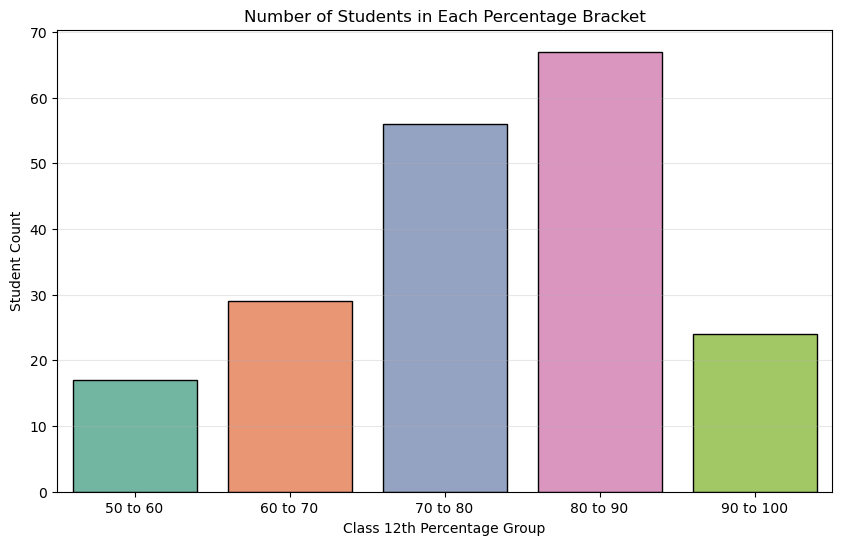

In [37]:
plt.figure(figsize=(10, 6))


sns.countplot(
    x='Percentage_Group', 
    data=df, 
    hue='Percentage_Group', 
    palette='Set2', 
    legend=False, 
    edgecolor='black'
)

plt.title('Number of Students in Each Percentage Bracket')
plt.xlabel('Class 12th Percentage Group')
plt.ylabel('Student Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

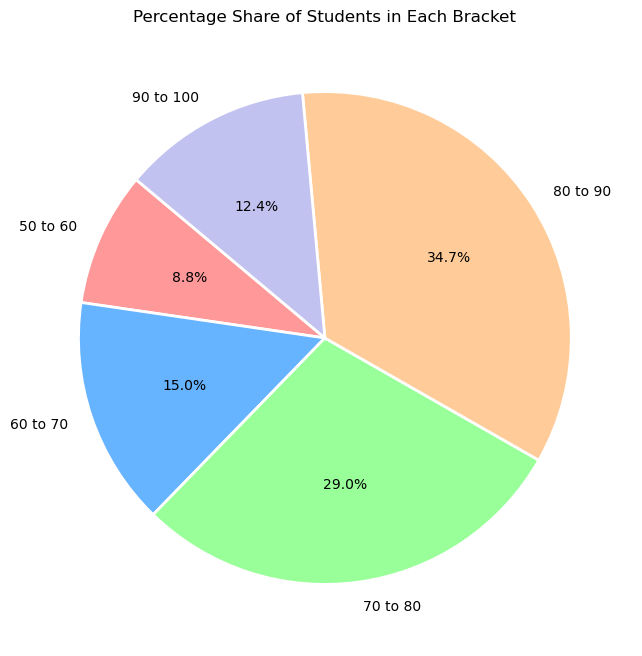

In [39]:
group_counts = df['Percentage_Group'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(
    group_counts.values, 
    labels=group_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Percentage Share of Students in Each Bracket')
plt.show()

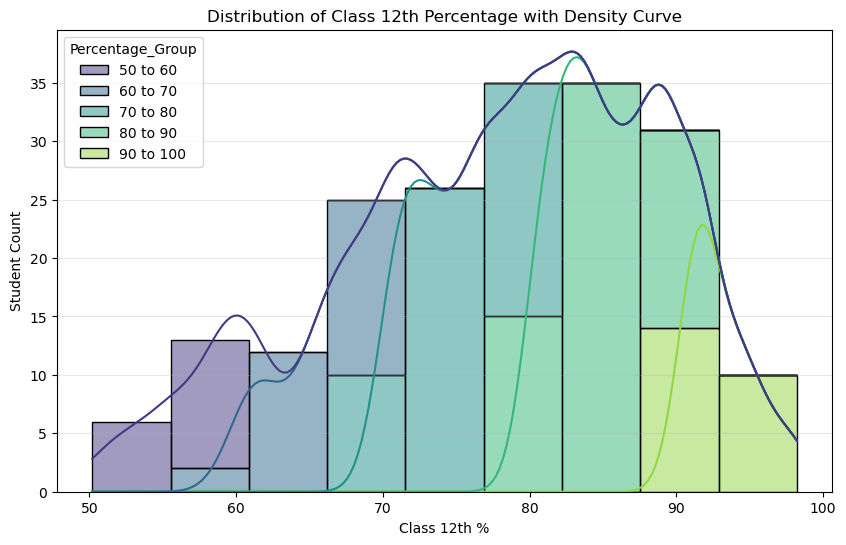

In [40]:
plt.figure(figsize=(10, 6))


sns.histplot(
    data=df, 
    x='Class12_Percentage', 
    hue='Percentage_Group', 
    multiple='stack', 
    palette='viridis', 
    kde=True,
    edgecolor='black'
)

plt.title('Distribution of Class 12th Percentage with Density Curve')
plt.xlabel('Class 12th %')
plt.ylabel('Student Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

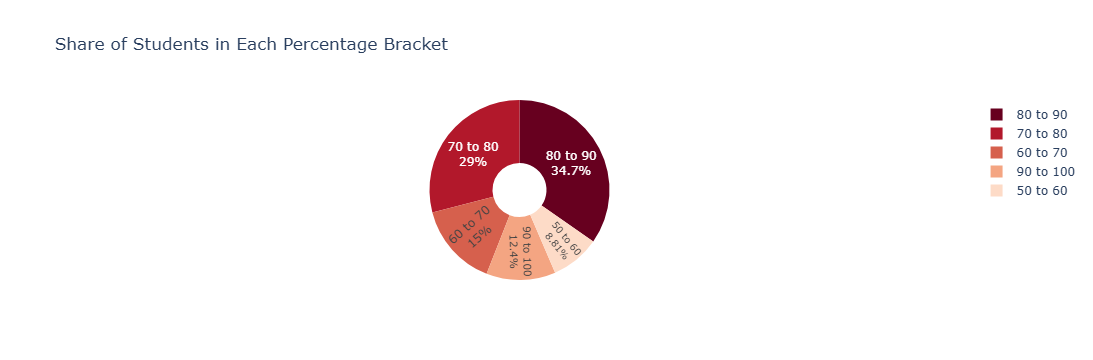

In [41]:
group_counts = df['Percentage_Group'].value_counts().reset_index()
group_counts.columns = ['Percentage_Group', 'Count']

fig = px.pie(
    group_counts, 
    values='Count', 
    names='Percentage_Group', 
    title='Share of Students in Each Percentage Bracket',
    color_discrete_sequence=px.colors.sequential.RdBu,
    hole=0.3
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()